# **Environmental Justice Analysis of Oil & Gas Spills in Colorado**
## Author: **David P. Adams**
### Date: **February 6, 2025**

---

### **Overview**
This notebook analyzes oil and gas spills in Colorado through an **environmental justice (EJ) lens**. The primary objectives include:
- Differentiating between **historical spills** (discovered later) and **recent spills** (reported as they occur).
- Evaluating **reporting delays** and their relationships to **socioeconomic factors**.
- Identifying **operator performance** in spill reporting.
- Mapping the **spatial distribution** of spills.
- Examining the **volume of spills** and whether larger spills occur disproportionately in certain areas.

### **Key Analyses**
1. **Data Processing & Cleaning**
   - Converts timestamps for **discovery and reporting**.
   - Categorizes spills into **historical vs. recent**.
   - Handles missing and extreme values in **socioeconomic and spill volume data**.

2. **Reporting Delays & Environmental Justice**
   - Conducts **OLS regressions** to determine how income, poverty, unemployment, and race impact reporting delays.
   - Compares **historical vs. recent spills** to examine shifts in reporting patterns.

3. **Operator Performance**
   - Identifies companies with the **most spills** and **longest reporting delays**.
   - Compares reporting behavior across operators.

4. **Spill Volume & Threshold Analysis**
   - Categorizes spills as **"More than Five Barrels" (Y/N)**.
   - Examines whether large spills are more common in marginalized areas.

5. **Geospatial Analysis**
   - Maps the **spatial distribution** of spills.
   - Visualizes spill locations by **Spill Type** (Historical vs. Recent).

### **Next Steps**
- Further refine **geospatial clustering** for spill locations.
- Analyze **changes in spill reporting trends over time**.
- Investigate **regulatory impacts** on reporting behavior.



In [1]:
import pandas as pd
from sqlalchemy import create_engine
import geopandas as gpd
from dotenv import load_dotenv
load_dotenv()

import os

# Database connection details from zshrc environment variables
#  use .env file for local development


db_name = 'colorado_spills'
user = os.getenv('DB_USER')
password = os.getenv('DB_PASSWORD')
host = os.getenv('DB_HOST')
port = os.getenv('DB_PORT')


# Create an engine to connect to the PostgreSQL database
engine = create_engine(f'postgresql+psycopg2://{user}:{password}@{host}:{port}/{db_name}')

# Read in the spills_with_demographics_geog as spills
spills = pd.read_sql_table('spills_with_demographics_geog', engine)



/home/dadams/miniconda3/envs/spatial_env2/lib/python3.10/site-packages/pandas/io/sql.py:1725: SAWarning: Did not recognize type 'geometry' of column 'geometry'
  self.meta.reflect(bind=self.con, only=[table_name], views=True)


In [2]:
# use longitude and latitude to create a GeoDataFrame from spills data
spills['geometry'] = gpd.points_from_xy(spills['Longitude'], spills['Latitude'])

In [3]:
# Create a GeoDataFrame from spills
spills_gdf = gpd.GeoDataFrame(spills, crs='EPSG:4326') 


In [4]:

# Ensure date columns are in datetime format
spills_gdf['Date of Discovery'] = pd.to_datetime(spills_gdf['Date of Discovery'])
spills_gdf['Initial Report Date'] = pd.to_datetime(spills_gdf['Initial Report Date'])



In [5]:

# Calculate Report Delay
spills_gdf['Report Delay (Days)'] = (spills_gdf['Initial Report Date'] - spills_gdf['Date of Discovery']).dt.days
spills_gdf['Report Delay (Days)'] = spills_gdf['Report Delay (Days)'].apply(lambda x: max(x, 0))


In [6]:
# Separate Historical vs. Recent Spills
historical_spills = spills_gdf[spills_gdf['Spill Type'] == 'Historical']
recent_spills = spills_gdf[spills_gdf['Spill Type'] == 'Recent']


In [7]:

# Compare Reporting Delay
report_delay_summary = spills_gdf.groupby('Spill Type')['Report Delay (Days)'].describe()
print(report_delay_summary)


              count       mean         std  min  25%  50%  75%     max
Spill Type                                                            
Historical   5828.0  20.987646  205.864644  0.0  0.0  1.0  2.0  9261.0
Recent      11062.0   4.075484   46.649970  0.0  0.0  1.0  2.0  2232.0


In [ ]:
!pip install matplotlib

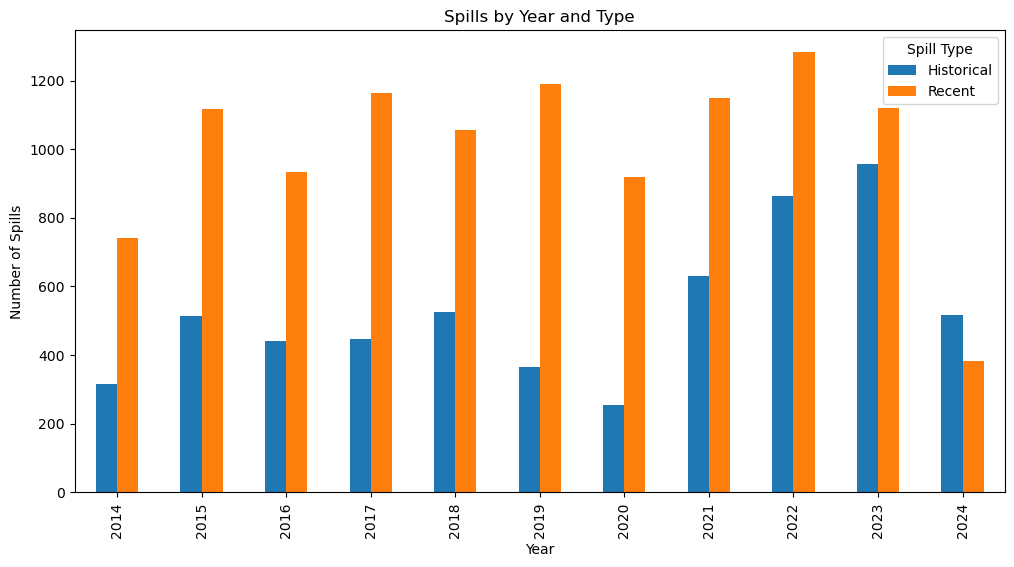

In [11]:
import matplotlib.pyplot as plt

# Compare Spill Trends Over Time
spills_by_year = spills_gdf.groupby(['Report Year', 'Spill Type']).size().unstack()
spills_by_year.plot(kind='bar', figsize=(12,6), title='Spills by Year and Type')
plt.xlabel('Year')
plt.ylabel('Number of Spills')
plt.legend(title='Spill Type')
plt.show()

In [12]:

# Operator Performance Analysis
operator_analysis = spills_gdf.groupby(['Operator', 'Spill Type'])['Report Delay (Days)'].mean().unstack()
operator_analysis['Total Spills'] = spills_gdf.groupby('Operator').size()
operator_analysis = operator_analysis.sort_values(by='Total Spills', ascending=False)
print(operator_analysis.head(10))


Spill Type                                  Historical     Recent  \
Operator                                                            
NOBLE ENERGY INC                              2.506479   1.448166   
KERR MCGEE OIL & GAS ONSHORE LP               6.273743  11.311961   
PDC ENERGY INC                                3.349296   2.347458   
CAERUS PICEANCE LLC                          10.082090   0.980371   
BONANZA CREEK ENERGY OPERATING COMPANY LLC   65.785714   1.126065   
KP KAUFFMAN COMPANY INC                      58.846154   8.448276   
CHEVRON USA INC                             251.076923   2.180723   
HIGHPOINT OPERATING CORPORATION               1.027778   0.922667   
CRESTONE PEAK RESOURCES OPERATING LLC         1.662420   0.962025   
LARAMIE ENERGY LLC                           23.833333   1.707386   

Spill Type                                  Total Spills  
Operator                                                  
NOBLE ENERGY INC                                    2

In [16]:
import statsmodels.api as sm
import numpy as np


# Environmental Justice Regressions
# Define independent variables for environmental justice analysis
independent_vars = ['median_household_income', 'percent_poverty', 'unemployment_rate', 'percent_white', 'percent_hispanic']

# Drop missing or infinite values from historical spills
historical_spills_clean = historical_spills[independent_vars + ['Report Delay (Days)']].replace([np.inf, -np.inf], np.nan).dropna()
X_hist = historical_spills_clean[independent_vars]
X_hist = sm.add_constant(X_hist)
y_hist = historical_spills_clean['Report Delay (Days)']
hist_model = sm.OLS(y_hist, X_hist).fit()
print("Historical Spills Regression Results")
print(hist_model.summary())

# Drop missing or infinite values from recent spills
recent_spills_clean = recent_spills[independent_vars + ['Report Delay (Days)']].replace([np.inf, -np.inf], np.nan).dropna()
X_recent = recent_spills_clean[independent_vars]
X_recent = sm.add_constant(X_recent)
y_recent = recent_spills_clean['Report Delay (Days)']
recent_model = sm.OLS(y_recent, X_recent).fit()
print("Recent Spills Regression Results")
print(recent_model.summary())

Historical Spills Regression Results
                             OLS Regression Results                            
Dep. Variable:     Report Delay (Days)   R-squared:                       0.021
Model:                             OLS   Adj. R-squared:                  0.020
Method:                  Least Squares   F-statistic:                     24.68
Date:                 Thu, 06 Feb 2025   Prob (F-statistic):           1.11e-24
Time:                         20:01:46   Log-Likelihood:                -39230.
No. Observations:                 5824   AIC:                         7.847e+04
Df Residuals:                     5818   BIC:                         7.851e+04
Df Model:                            5                                         
Covariance Type:             nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

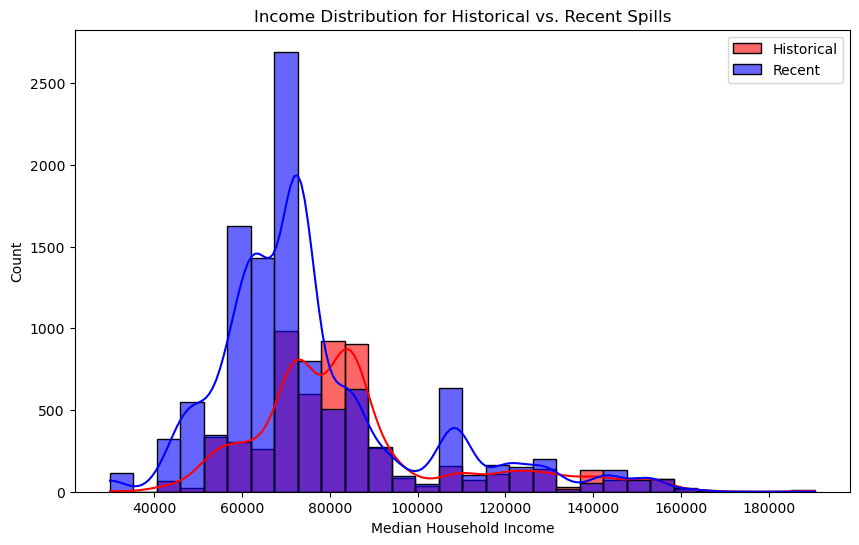

In [18]:
import seaborn as sns
# Check spatial distribution of spills
plt.figure(figsize=(10,6))
sns.histplot(historical_spills['median_household_income'], bins=30, kde=True, label='Historical', color='red', alpha=0.6)
sns.histplot(recent_spills['median_household_income'], bins=30, kde=True, label='Recent', color='blue', alpha=0.6)
plt.legend()
plt.title('Income Distribution for Historical vs. Recent Spills')
plt.xlabel('Median Household Income')
plt.ylabel('Count')
plt.show()


In [20]:
# Operator comparison of historical vs recent spills
operator_spill_type = spills_gdf.groupby(['Operator', 'Spill Type']).size().unstack()
operator_spill_type['Total Spills'] = operator_spill_type.sum(axis=1)
print(operator_spill_type.sort_values(by='Total Spills', ascending=False).head(10))


Spill Type                                  Historical  Recent  Total Spills
Operator                                                                    
NOBLE ENERGY INC                                1775.0   627.0        2402.0
KERR MCGEE OIL & GAS ONSHORE LP                 1432.0   811.0        2243.0
PDC ENERGY INC                                   710.0   472.0        1182.0
CAERUS PICEANCE LLC                              134.0   917.0        1051.0
BONANZA CREEK ENERGY OPERATING COMPANY LLC        56.0   587.0         643.0
KP KAUFFMAN COMPANY INC                           91.0   377.0         468.0
CHEVRON USA INC                                   52.0   415.0         467.0
HIGHPOINT OPERATING CORPORATION                   36.0   375.0         411.0
CRESTONE PEAK RESOURCES OPERATING LLC            157.0   237.0         394.0
LARAMIE ENERGY LLC                                24.0   352.0         376.0


In [24]:
volume_comparison_by_type = spills_gdf.groupby(['Spill Type', 'More than Five Barrels']).size().unstack()
print(volume_comparison_by_type)


More than Five Barrels  False  True 
Spill Type                          
Historical               5271    557
Recent                   6731   4331


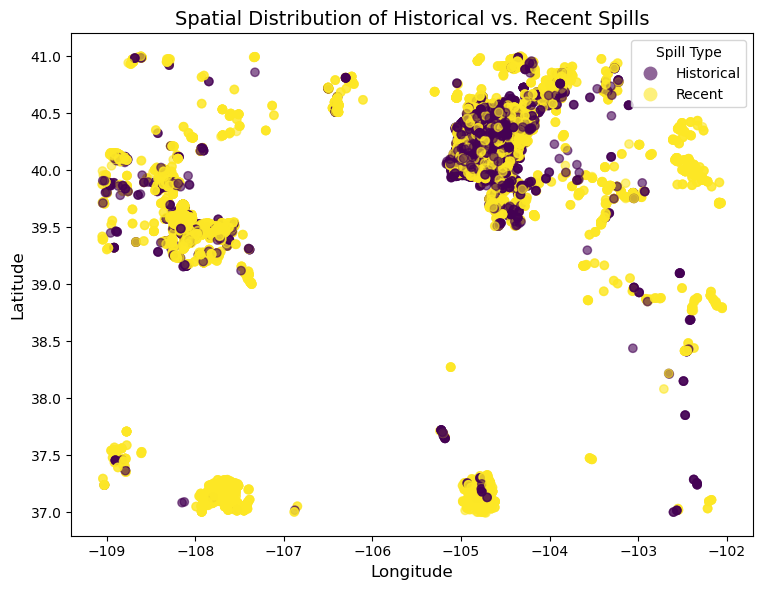

In [27]:
import matplotlib.pyplot as plt
import geopandas as gpd

# Ensure spills_gdf is already a GeoDataFrame with the necessary data
# spills_gdf = gpd.GeoDataFrame(...)

# Create a plot for the spatial distribution of spills
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the GeoDataFrame with optimizations
spills_gdf.plot(
    ax=ax,
    marker='o', 
    alpha=0.6,  # Adjust transparency for better visibility
    column='Spill Type', 
    legend=True, 
    legend_kwds={'title': "Spill Type"},  # Correctly specify the legend title
    cmap='viridis'  # Use a colormap for better visual distinction
)

# Set plot title and labels
ax.set_title('Spatial Distribution of Historical vs. Recent Spills', fontsize=14)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)

# Improve layout
plt.tight_layout()

# Display the plot
plt.show()


In [ ]:
!pip install contextily

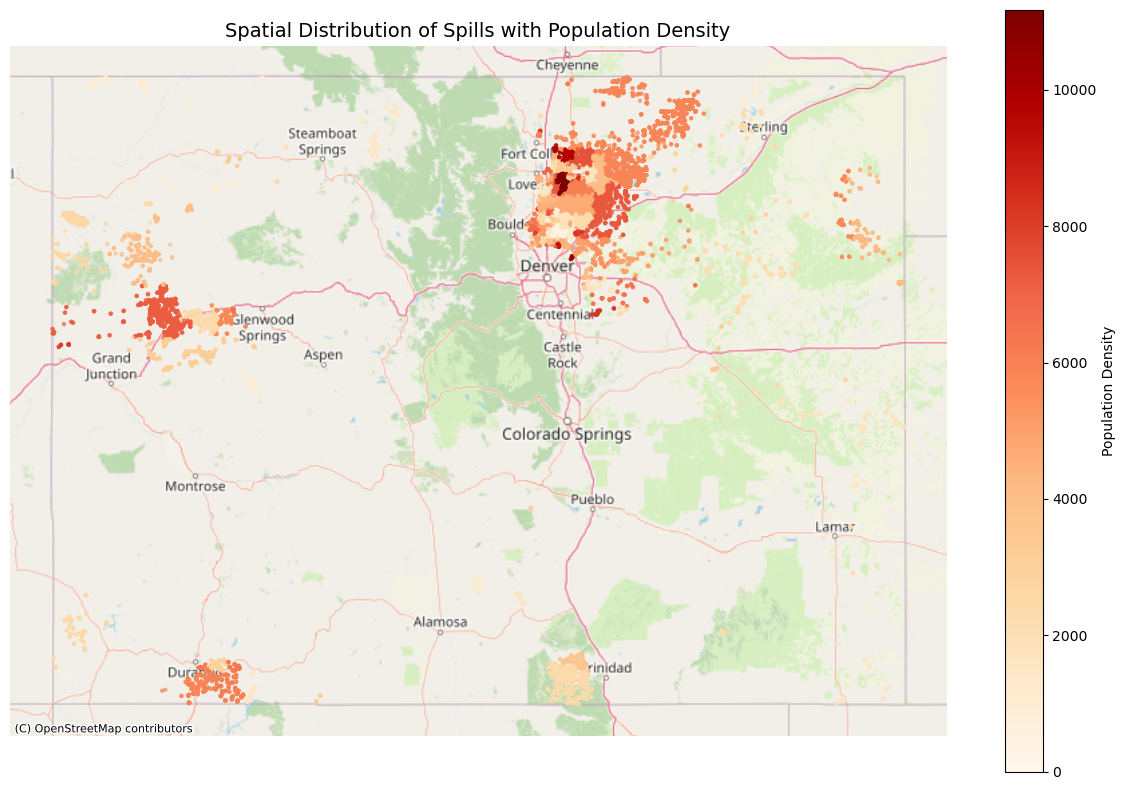

In [30]:
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as ctx

# Ensure spills_gdf is in the Web Mercator CRS for compatibility with basemaps
spills_gdf = spills_gdf.to_crs(epsg=3857)

# Create a plot for the spatial distribution and population density
fig, ax = plt.subplots(figsize=(12, 8))

# Plot with population density
spills_gdf.plot(
    ax=ax,
    column='total_population',
    cmap='OrRd',  # Use a color map suggestive of density/intensity
    legend=True,
    legend_kwds={'label': "Population Density"},
    alpha=0.6,
    markersize=5  # Adjust marker size for better distinction
)

# Add a basemap for Colorado using contextily
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)  # Use OpenStreetMap as the base

# Set plot title and labels
ax.set_title('Spatial Distribution of Spills with Population Density', fontsize=14)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)

# Remove axis for a clean look
ax.set_axis_off()

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()


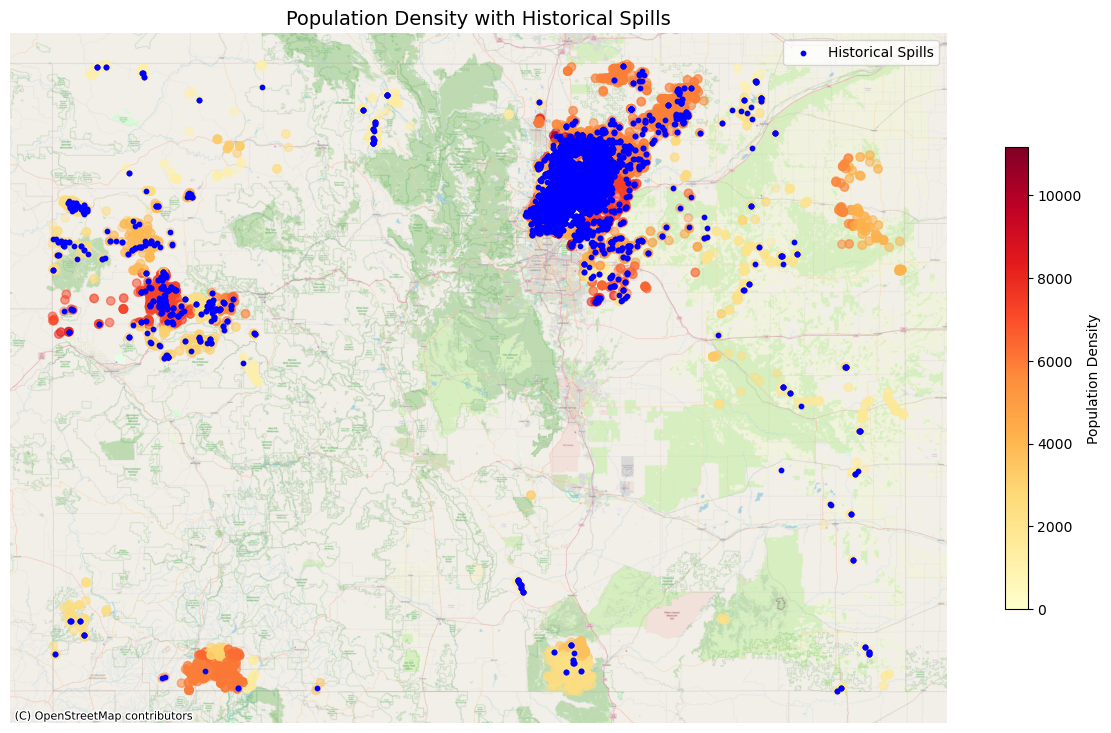

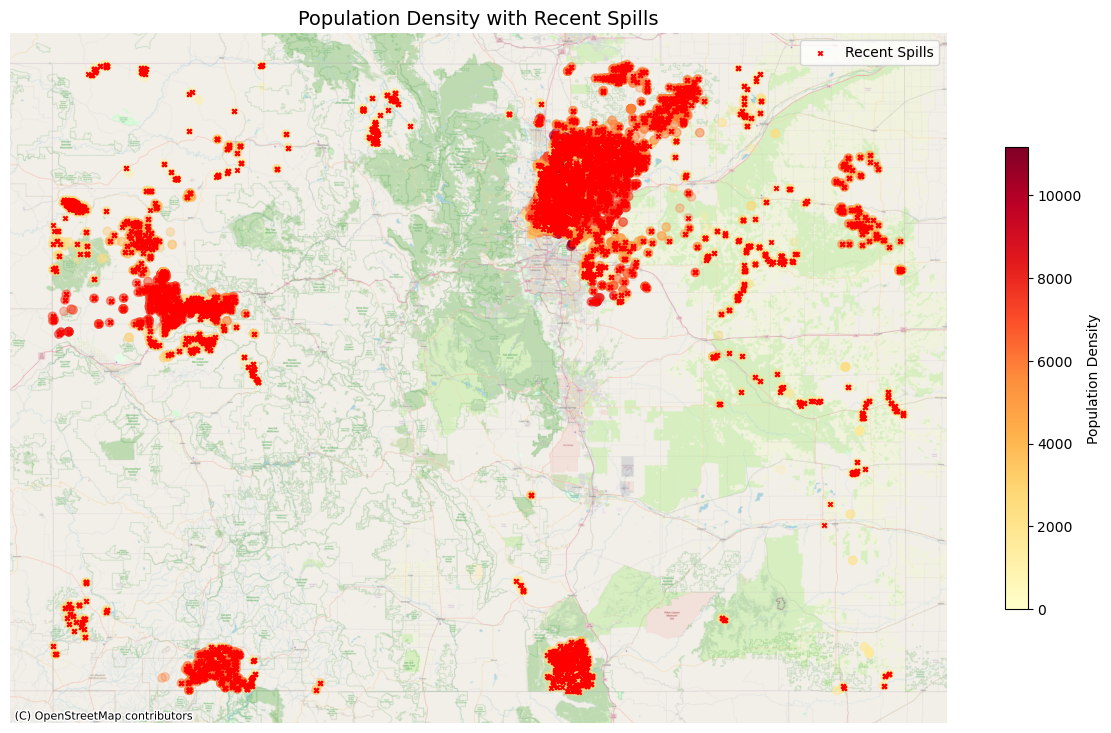

In [32]:
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as ctx

# Ensure spills_gdf is already a GeoDataFrame and projected into Web Mercator for basemaps
spills_gdf = spills_gdf.to_crs(epsg=3857)

# Filter historical and recent spills
historical_spills = spills_gdf[spills_gdf['Spill Type'] == 'Historical']
recent_spills = spills_gdf[spills_gdf['Spill Type'] == 'Recent']

# Create the first map: Historical Spills and Population Density
fig, ax1 = plt.subplots(figsize=(12, 8))
spills_gdf.plot(
    ax=ax1,
    column='total_population',
    cmap='YlOrRd',
    legend=True,
    legend_kwds={'label': "Population Density", 'shrink': 0.6},
    alpha=0.3
)
historical_spills.plot(
    ax=ax1,
    color='blue',
    markersize=10,
    marker='o',
    label='Historical Spills'
)
ctx.add_basemap(ax1, source=ctx.providers.OpenStreetMap.Mapnik, zoom=10)
ax1.set_title('Population Density with Historical Spills', fontsize=14)
ax1.legend(loc='upper right')
ax1.set_axis_off()
plt.tight_layout()

# Create the second map: Recent Spills and Population Density
fig, ax2 = plt.subplots(figsize=(12, 8))
spills_gdf.plot(
    ax=ax2,
    column='total_population',
    cmap='YlOrRd',
    legend=True,
    legend_kwds={'label': "Population Density", 'shrink': 0.6},
    alpha=0.3
)
recent_spills.plot(
    ax=ax2,
    color='red',
    markersize=10,
    marker='x',
    label='Recent Spills'
)
ctx.add_basemap(ax2, source=ctx.providers.OpenStreetMap.Mapnik, zoom=10)
ax2.set_title('Population Density with Recent Spills', fontsize=14)
ax2.legend(loc='upper right')
ax2.set_axis_off()
plt.tight_layout()

# Display both plots
plt.show()
